In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup OK")

Setup OK


In [4]:
import pandas as pd

df = pd.read_csv("combinenew.csv")

print(df.head())
print(df.shape)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3328\1645769912.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combinenew.csv")


   Destination Port   Flow Duration   Total Fwd Packets  \
0             54865             3.0                 2.0   
1             55054           109.0                 1.0   
2             55055            52.0                 1.0   
3             46236            34.0                 1.0   
4             54863             3.0                 2.0   

    Total Backward Packets  Total Length of Fwd Packets  \
0                      0.0                         12.0   
1                      1.0                          6.0   
2                      1.0                          6.0   
3                      1.0                          6.0   
4                      0.0                         12.0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                           0.0                     6.0   
1                           6.0                     6.0   
2                           6.0                     6.0   
3                           6.0                     6.

In [5]:
df = pd.read_csv("combinenew.csv", low_memory=False)

In [6]:
print(df.columns)
print(df.info())

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [7]:
df.shape

(2830744, 79)

In [8]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [9]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [10]:
df['Label'].value_counts().head(10)

KeyError: 'Label'

In [11]:
df[' Label'].value_counts().head(10)

 Label
BENIGN              2273097
DoS Hulk             231073
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Name: count, dtype: int64

In [12]:
# remove spaces in column names
df.columns = df.columns.str.strip()

In [13]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [14]:
# drop missing values
df = df.dropna()

In [15]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3328\3611995654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)


In [16]:
df = df.copy()

In [17]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [18]:
df = df.select_dtypes(include=['number'])

In [19]:
X = df.drop('Label', axis=1)
y = df['Label']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2829385 entries, 0 to 2830742
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow Duration                float64
 1   Total Fwd Packets            float64
 2   Total Backward Packets       float64
 3   Total Length of Fwd Packets  float64
 4   Total Length of Bwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Fwd Packet Length Std        float64
 9   Bwd Packet Length Max        float64
 10  Bwd Packet Length Min        float64
 11  Bwd Packet Length Mean       float64
 12  Bwd Packet Length Std        float64
 13  Flow Bytes/s                 float64
 14  Flow Packets/s               float64
 15  Flow IAT Mean                float64
 16  Flow IAT Std                 float64
 17  Flow IAT Max                 float64
 18  Flow IAT Min                 float64
 19  Fwd I

In [22]:
print("Dataset shape:", df.shape)

Dataset shape: (2829385, 78)


In [23]:
df['Label'].value_counts()

Label
1    2829385
Name: count, dtype: int64

In [24]:
df['Label'].value_counts(normalize=True) * 100

Label
1    100.0
Name: proportion, dtype: float64

In [25]:
df['Label'].value_counts()


Label
1    2829385
Name: count, dtype: int64

In [26]:
df['Label'].value_counts().head(10)

Label
1    2829385
Name: count, dtype: int64

In [27]:
import pandas as pd

df = pd.read_csv("combinednew.csv")
df.columns = df.columns.str.strip()

FileNotFoundError: [Errno 2] No such file or directory: 'combinednew.csv'

In [28]:
import pandas as pd

df = pd.read_csv("combinenew.csv")
df.columns = df.columns.str.strip()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3328\687330980.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combinenew.csv")


In [29]:
import pandas as pd

df = pd.read_csv("combinenew.csv" , low_memory=False)
df.columns = df.columns.str.strip()

In [30]:
df['Label'].value_counts()

Label
BENIGN                      2273097
DoS Hulk                     231073
PortScan                     158930
DDoS                         128027
DoS GoldenEye                 10293
FTP-Patator                    7938
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1966
Web Attack_Brute Force         1507
Web Attack_XSS                  652
Infiltration                     36
Web Attack_Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64

In [31]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [32]:
df['Label'].value_counts()

Label
0    2273097
1     557647
Name: count, dtype: int64

In [33]:
df['Label'].value_counts(normalize=True) * 100

Label
0    80.300338
1    19.699662
Name: proportion, dtype: float64

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
print(X.shape)
print(y.shape)

(2830744, 78)
(2830744,)


In [36]:
df_sample = df.sample(n=200000, random_state=42)

In [37]:
X = df_sample.drop('Label', axis=1)
y = df_sample['Label']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
df_sample.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2075756,64105,13.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
267934,53,30774.0,1.0,1.0,51.0,67.0,51.0,51.0,51.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1507119,59996,1680.0,3.0,0.0,31.0,0.0,31.0,0.0,10.333333,17.897858,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
361932,8083,44.0,1.0,1.0,2.0,6.0,2.0,2.0,2.000000,0.000000,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2153290,53,668.0,1.0,1.0,51.0,89.0,51.0,51.0,51.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [40]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 2075756 to 491490
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             200000 non-null  object 
 1   Flow Duration                200000 non-null  float64
 2   Total Fwd Packets            200000 non-null  float64
 3   Total Backward Packets       200000 non-null  float64
 4   Total Length of Fwd Packets  200000 non-null  float64
 5   Total Length of Bwd Packets  200000 non-null  float64
 6   Fwd Packet Length Max        200000 non-null  float64
 7   Fwd Packet Length Min        200000 non-null  float64
 8   Fwd Packet Length Mean       200000 non-null  float64
 9   Fwd Packet Length Std        200000 non-null  float64
 10  Bwd Packet Length Max        200000 non-null  float64
 11  Bwd Packet Length Min        200000 non-null  float64
 12  Bwd Packet Length Mean       200000 non-null  float64
 13

In [41]:
df_sample = df_sample.select_dtypes(include=['number'])

In [42]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 2075756 to 491490
Data columns (total 78 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow Duration                200000 non-null  float64
 1   Total Fwd Packets            200000 non-null  float64
 2   Total Backward Packets       200000 non-null  float64
 3   Total Length of Fwd Packets  200000 non-null  float64
 4   Total Length of Bwd Packets  200000 non-null  float64
 5   Fwd Packet Length Max        200000 non-null  float64
 6   Fwd Packet Length Min        200000 non-null  float64
 7   Fwd Packet Length Mean       200000 non-null  float64
 8   Fwd Packet Length Std        200000 non-null  float64
 9   Bwd Packet Length Max        200000 non-null  float64
 10  Bwd Packet Length Min        200000 non-null  float64
 11  Bwd Packet Length Mean       200000 non-null  float64
 12  Bwd Packet Length Std        200000 non-null  float64
 13

In [43]:
df_sample.select_dtypes(include=['object']).columns

Index([], dtype='object')

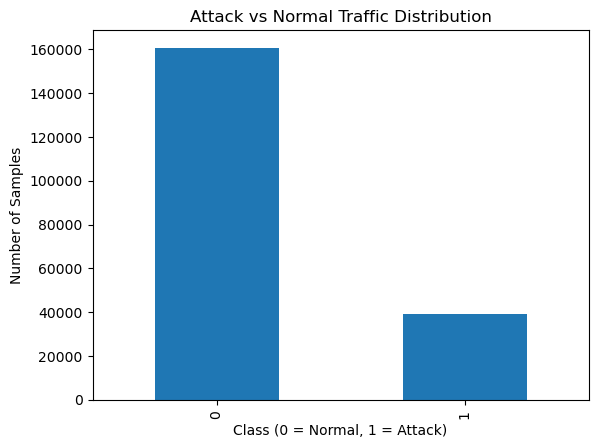

In [44]:
import matplotlib.pyplot as plt

df_sample['Label'].value_counts().plot(kind='bar')
plt.title("Attack vs Normal Traffic Distribution")
plt.xlabel("Class (0 = Normal, 1 = Attack)")
plt.ylabel("Number of Samples")
plt.show()

In [45]:
df_raw['Label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Traffic Types")
plt.show()

NameError: name 'df_raw' is not defined

In [46]:
df_raw['Label'].value_counts().head(10)

NameError: name 'df_raw' is not defined

In [47]:
df_raw = pd.read_csv("combinednew.csv")
df_raw.columns = df_raw.columns.str.strip()

df = df_raw.copy()

FileNotFoundError: [Errno 2] No such file or directory: 'combinednew.csv'

In [ ]:
df_raw = pd.read_csv("combinenew.csv")
df_raw.columns = df_raw.columns.str.strip()

df = df_raw.copy()

In [48]:
df_raw['Label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Traffic Types")
plt.show()

NameError: name 'df_raw' is not defined

In [49]:
df_sample.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [50]:
df = pd.read_csv("combinenew.csv")
df.columns = df.columns.str.strip()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3328\3287181595.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combinenew.csv")


In [51]:
df = pd.read_csv("combinenew.csv" , low_memory=false)
df.columns = df.columns.str.strip()

NameError: name 'false' is not defined

In [52]:
df = pd.read_csv("combinenew.csv", low_memory=False)
df.columns = df.columns.str.strip()

In [53]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [54]:
df_analysis = df.copy()

In [55]:
df_ml = df.select_dtypes(include=['number'])

In [56]:
X = df_ml.drop('Label', axis=1)
y = df_ml['Label']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow Duration                float64
 1   Total Fwd Packets            float64
 2   Total Backward Packets       float64
 3   Total Length of Fwd Packets  float64
 4   Total Length of Bwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Fwd Packet Length Std        float64
 9   Bwd Packet Length Max        float64
 10  Bwd Packet Length Min        float64
 11  Bwd Packet Length Mean       float64
 12  Bwd Packet Length Std        float64
 13  Flow Bytes/s                 float64
 14  Flow Packets/s               float64
 15  Flow IAT Mean                float64
 16  Flow IAT Std                 float64
 17  Flow IAT Max                 float64
 18  Flow IAT Min                 float64
 19  

In [59]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             object 
 1   Flow Duration                float64
 2   Total Fwd Packets            float64
 3   Total Backward Packets       float64
 4   Total Length of Fwd Packets  float64
 5   Total Length of Bwd Packets  float64
 6   Fwd Packet Length Max        float64
 7   Fwd Packet Length Min        float64
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        float64
 11  Bwd Packet Length Min        float64
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 float64
 19  

In [60]:
df.isnull().sum().sum()

np.int64(1435)

In [61]:
df_ml.isnull().sum().sum()

np.int64(1435)

In [62]:
df_analysis.shape
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             object 
 1   Flow Duration                float64
 2   Total Fwd Packets            float64
 3   Total Backward Packets       float64
 4   Total Length of Fwd Packets  float64
 5   Total Length of Bwd Packets  float64
 6   Fwd Packet Length Max        float64
 7   Fwd Packet Length Min        float64
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        float64
 11  Bwd Packet Length Min        float64
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 float64
 19  

In [63]:
df_ml.shape
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow Duration                float64
 1   Total Fwd Packets            float64
 2   Total Backward Packets       float64
 3   Total Length of Fwd Packets  float64
 4   Total Length of Bwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Fwd Packet Length Std        float64
 9   Bwd Packet Length Max        float64
 10  Bwd Packet Length Min        float64
 11  Bwd Packet Length Mean       float64
 12  Bwd Packet Length Std        float64
 13  Flow Bytes/s                 float64
 14  Flow Packets/s               float64
 15  Flow IAT Mean                float64
 16  Flow IAT Std                 float64
 17  Flow IAT Max                 float64
 18  Flow IAT Min                 float64
 19  

In [64]:
df_ml.isnull().sum().sum()


np.int64(1435)

In [65]:
missing = df_ml.isnull().sum()
missing[missing > 0]

Flow Duration                  1
Total Fwd Packets              1
Total Backward Packets         1
Total Length of Fwd Packets    1
Total Length of Bwd Packets    1
                              ..
Active Min                     1
Idle Mean                      1
Idle Std                       1
Idle Max                       1
Idle Min                       1
Length: 77, dtype: int64

In [66]:
df_ml[df_ml.isnull().any(axis=1)]

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
6796,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
14739,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,44.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
15047,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
209728,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
238569,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2767532,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2791593,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2809052,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2824846,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [67]:
df_ml[df_ml.isnull().any(axis=1)].shape

(1359, 78)

In [68]:
missing = df_ml.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Flow Bytes/s                   1359
Flow Duration                     1
Total Backward Packets            1
Total Length of Fwd Packets       1
Total Length of Bwd Packets       1
                               ... 
Active Min                        1
Idle Mean                         1
Idle Std                          1
Idle Max                          1
Idle Min                          1
Length: 77, dtype: int64

In [69]:
df_ml = df_ml.dropna()

In [70]:
print(df_ml.isnull().sum().sum())

0


In [71]:
df_ml.shape

(2829385, 78)

In [72]:
df_ml.shape
df_ml.info()
df_ml.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2829385 entries, 0 to 2830742
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow Duration                float64
 1   Total Fwd Packets            float64
 2   Total Backward Packets       float64
 3   Total Length of Fwd Packets  float64
 4   Total Length of Bwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Fwd Packet Length Std        float64
 9   Bwd Packet Length Max        float64
 10  Bwd Packet Length Min        float64
 11  Bwd Packet Length Mean       float64
 12  Bwd Packet Length Std        float64
 13  Flow Bytes/s                 float64
 14  Flow Packets/s               float64
 15  Flow IAT Mean                float64
 16  Flow IAT Std                 float64
 17  Flow IAT Max                 float64
 18  Flow IAT Min                 float64
 19  Fwd I

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [73]:
df_ml.duplicated().sum()

np.int64(629571)

In [74]:
df_ml = df_ml.drop_duplicates()

In [75]:
df_ml.duplicated().sum()

np.int64(0)

In [76]:
df_ml["Label"].value_counts()

Label
0    1863312
1     336502
Name: count, dtype: int64

In [77]:
X = df_ml.drop(columns=["Label"])
y = df_ml["Label"]

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1759851, 77)
X_test: (439963, 77)
y_train: (1759851,)
y_test: (439963,)


In [80]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
Label
0    0.847031
1    0.152969
Name: proportion, dtype: float64

Test distribution:
Label
0    0.847033
1    0.152967
Name: proportion, dtype: float64


In [81]:
df_analysis.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [82]:
import matplotlib.pyplot as plt

top_attacks = df_analysis["label"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_attacks.plot(kind="bar")
plt.title("Top 10 Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

KeyError: 'label'

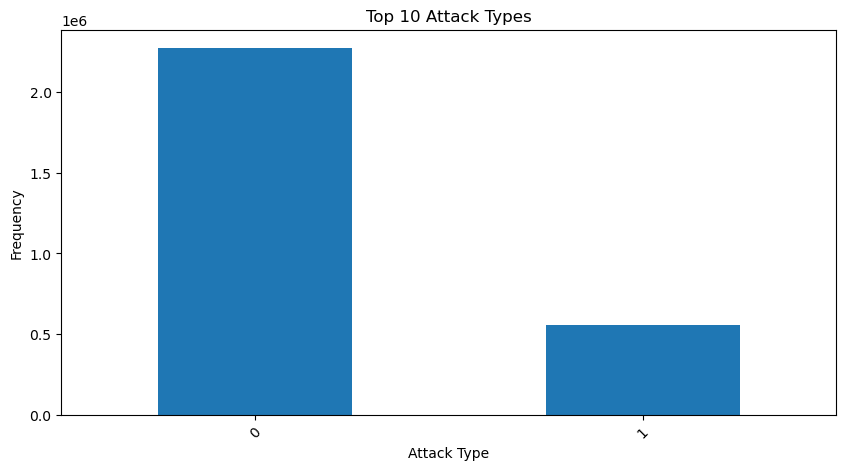

In [83]:
import matplotlib.pyplot as plt

top_attacks = df_analysis["Label"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_attacks.plot(kind="bar")
plt.title("Top 10 Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [84]:
df_analysis.columns = df_raw.columns.str.strip()
df_analysis['Label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Traffic Types")
plt.show()

NameError: name 'df_raw' is not defined

In [85]:
df_original = pd.read_csv("combinenew.csv")
import matplotlib.pyplot as plt

top_attacks = (
    df_original[df_original["Label"] != "BENIGN"]["Label"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
top_attacks.plot(kind="bar")
plt.title("Top 10 Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3328\2095316307.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("combinenew.csv")


KeyError: 'Label'

In [86]:
df_original = pd.read_csv("combinenew.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3328\323396778.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("combinenew.csv")


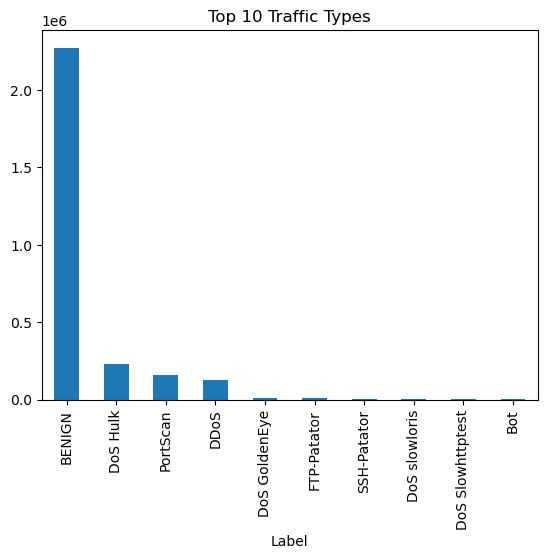

In [87]:

df_original.columns = df_original.columns.str.strip()

df_original['Label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Traffic Types")
plt.show()

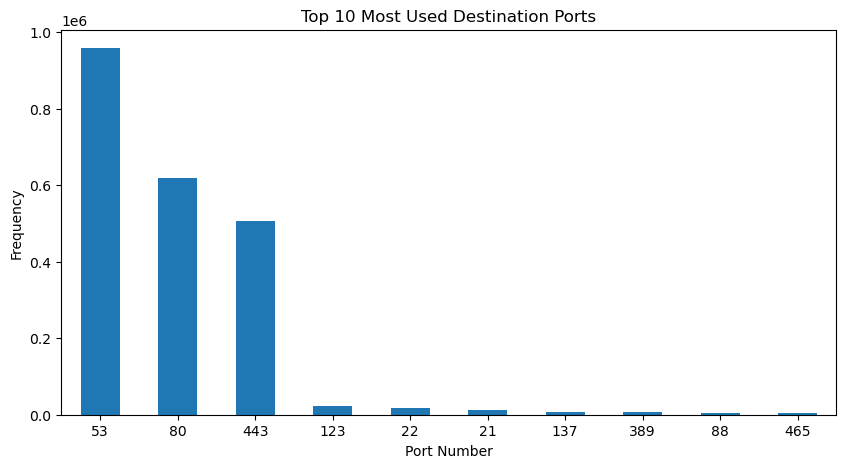

In [88]:
top_ports = df_analysis["Destination Port"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_ports.plot(kind="bar")
plt.title("Top 10 Most Used Destination Ports")
plt.xlabel("Port Number")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

In [89]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             object 
 1   Flow Duration                float64
 2   Total Fwd Packets            float64
 3   Total Backward Packets       float64
 4   Total Length of Fwd Packets  float64
 5   Total Length of Bwd Packets  float64
 6   Fwd Packet Length Max        float64
 7   Fwd Packet Length Min        float64
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        float64
 11  Bwd Packet Length Min        float64
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 float64
 19  

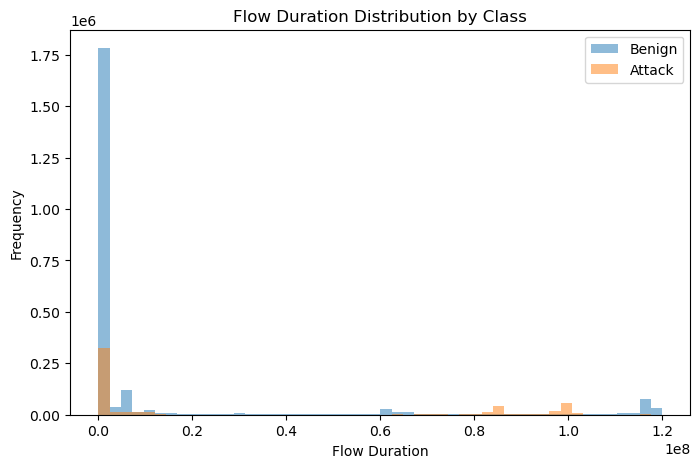

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_analysis[df_analysis["Label"] == 0]["Flow Duration"],
    bins=50,
    alpha=0.5,
    label="Benign"
)

plt.hist(
    df_analysis[df_analysis["Label"] == 1]["Flow Duration"],
    bins=50,
    alpha=0.5,
    label="Attack"
)

plt.legend()
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")
plt.title("Flow Duration Distribution by Class")
plt.show()

C:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: supplied range of [-inf, 18.603002292412988] is not finite

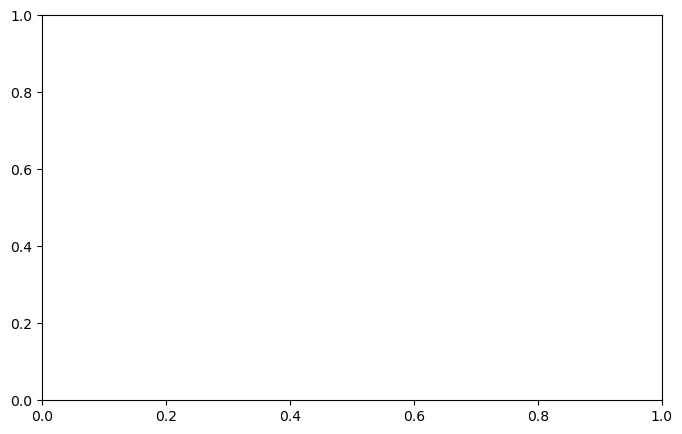

In [91]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(df_analysis[df_analysis["Label"]==0]["Flow Duration"]),
    bins=50,
    alpha=0.5,
    label="Benign"
)

plt.hist(
    np.log1p(df_analysis[df_analysis["Label"]==1]["Flow Duration"]),
    bins=50,
    alpha=0.5,
    label="Attack"
)

plt.xlabel("log(Flow Duration + 1)")
plt.ylabel("Frequency")
plt.title("Flow Duration Distribution (Log Scale)")
plt.legend()
plt.show()

In [ ]:
benign = df_analysis[df_analysis["Label"]==0]["Flow Duration"]
attack = df_analysis[df_analysis["Label"]==1]["Flow Duration"]

plt.hist(
    np.log1p(benign[benign >= 0]),
    bins=50,
    alpha=0.5,
    label="Benign"
)

plt.hist(
    np.log1p(attack[attack >= 0]),
    bins=50,
    alpha=0.5,
    label="Attack"
)

In [92]:
import pandas as pd

# only numeric columns
numeric_df = df_analysis.select_dtypes(include=['number'])

# correlation with label
corr = numeric_df.corr()["Label"].sort_values(ascending=False)

# remove label itself
top_corr = corr.drop("Label").head(10)
bottom_corr = corr.drop("Label").tail(10)

print("Top positive correlations (attack-related):")
print(top_corr)

print("\nTop negative correlations (benign-related):")
print(bottom_corr)

Top positive correlations (attack-related):
Bwd Packet Length Std     0.510216
Bwd Packet Length Max     0.492007
Bwd Packet Length Mean    0.484189
Avg Bwd Segment Size      0.484189
Packet Length Std         0.470252
Max Packet Length         0.454054
Packet Length Variance    0.453847
Fwd IAT Std               0.422755
Packet Length Mean        0.414059
Average Packet Size       0.413037
Name: Label, dtype: float64

Top negative correlations (benign-related):
Bwd Packet Length Min   -0.281838
Min Packet Length       -0.303164
Bwd PSH Flags                 NaN
Bwd URG Flags                 NaN
Fwd Avg Bytes/Bulk            NaN
Fwd Avg Packets/Bulk          NaN
Fwd Avg Bulk Rate             NaN
Bwd Avg Bytes/Bulk            NaN
Bwd Avg Packets/Bulk          NaN
Bwd Avg Bulk Rate             NaN
Name: Label, dtype: float64


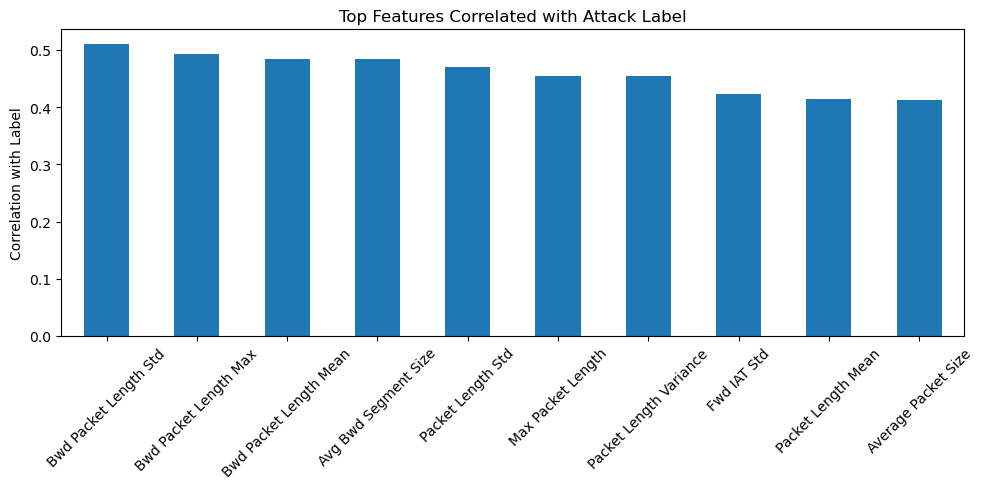

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_corr.plot(kind="bar")

plt.title("Top Features Correlated with Attack Label")
plt.ylabel("Correlation with Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df_ml,
    test_size=0.8,
    random_state=42,
    stratify=df_ml["Label"]
)

In [95]:
X = df_sample.drop(columns=["Label"])
y = df_sample["Label"]

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [98]:
import numpy as np

np.isinf(X_train).sum()

Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
                              ..
Active Min                     0
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Length: 77, dtype: int64

In [99]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [100]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    solver="saga"
)

log_reg.fit(X_train_scaled, y_train)

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, solver='saga')

In [103]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    solver="saga",
    tol=1e-3
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, solver='saga', tol=0.001)

In [104]:
y_pred = log_reg.predict(X_test_scaled)

In [105]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9593035809666678
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     74533
           1       0.96      0.76      0.85     13460

    accuracy                           0.96     87993
   macro avg       0.96      0.88      0.91     87993
weighted avg       0.96      0.96      0.96     87993



In [106]:
X = df_ml.drop(columns=["Label"])
y = df_ml["Label"]

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [108]:
import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=3000,
    solver="saga",
    tol=1e-3
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=3000, solver='saga', tol=0.001)

In [111]:
y_pred = log_reg.predict(X_test_scaled)

In [112]:
y_pred[:20]

array([0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [113]:
%whos

Variable                Type                  Data/Info
-------------------------------------------------------
LogisticRegression      type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
StandardScaler          type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>
         Flow Duration  T<...>199814 rows x 77 columns]
         Flow Duration  T<...>439963 rows x 77 columns]
X_test_scaled           ndarray               439963x77: 33877151 elems, type `float64`, 271017208 bytes (258.46215057373047 Mb)
         Flow Duration  T<...>759851 rows x 77 columns]
X_train_scaled          ndarray               1759851x77: 135508527 elems, type `float64`, 1084068216 bytes (1033.848014831543 Mb)
accuracy_score          function              <function accuracy_score at 0x0000019CFACA3920>
bottom_corr             Series                Bwd Packet Length Min   -<...>me: Label, dtype: float64
classification_report   function              <function clas

In [114]:
print("still alive")

still alive


In [115]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9590783770453425
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    372663
           1       0.97      0.76      0.85     67300

    accuracy                           0.96    439963
   macro avg       0.96      0.88      0.91    439963
weighted avg       0.96      0.96      0.96    439963



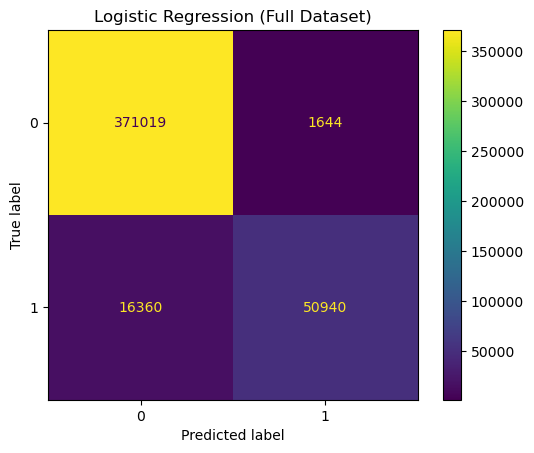

In [116]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression (Full Dataset)")
plt.show()

In [117]:
from sklearn.metrics import roc_auc_score

y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.9840673596526162


In [118]:
from sklearn.ensemble import RandomForestClassifier


In [119]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [120]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [122]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

NameError: name 'y_pred_rf' is not defined

In [123]:
print(hasattr(rf, "estimators_"))

True


In [124]:
y_pred_rf = rf.predict(X_test)

In [125]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

Accuracy: 0.9987771698983778
              precision    recall  f1-score   support

           0     0.9991    0.9994    0.9993    372663
           1     0.9968    0.9952    0.9960     67300

    accuracy                         0.9988    439963
   macro avg     0.9980    0.9973    0.9976    439963
weighted avg     0.9988    0.9988    0.9988    439963



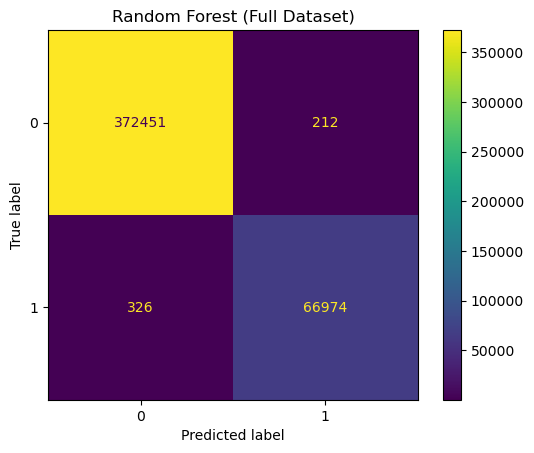

In [126]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Random Forest (Full Dataset)")
plt.show()

In [127]:
from sklearn.metrics import roc_auc_score

y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

ROC-AUC: 0.9998914077105042


In [128]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
12,Bwd Packet Length Std,0.128946
11,Bwd Packet Length Mean,0.066756
64,Subflow Bwd Bytes,0.052079
53,Avg Bwd Segment Size,0.049903
40,Packet Length Std,0.048787
41,Packet Length Variance,0.048308
9,Bwd Packet Length Max,0.047212
39,Packet Length Mean,0.038679
51,Average Packet Size,0.035632
38,Max Packet Length,0.034674


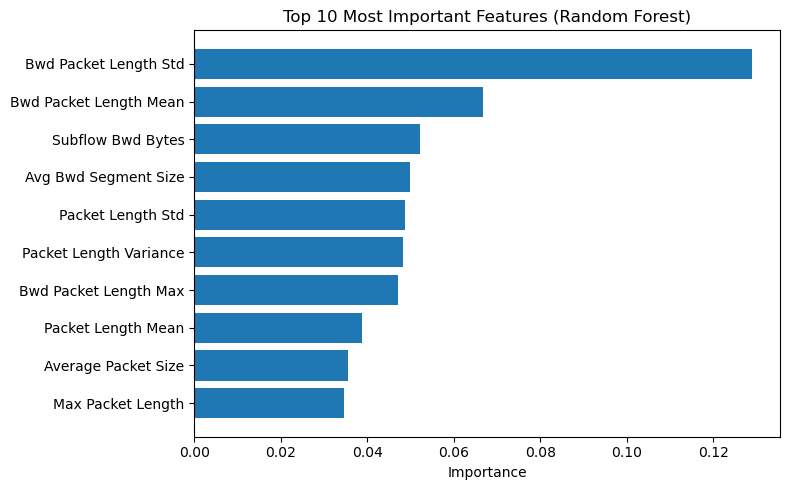

In [129]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [130]:
pip install shap

In [131]:
import shap
print (shap.__version__)

0.52.0


In [132]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [134]:
import shap

In [135]:
explainer = shap.TreeExplainer(rf)

In [136]:
X_test_shap = X_test.sample(
    n=1000,
    random_state=42
)

In [137]:
shap_values = explainer.shap_values(X_test_shap)

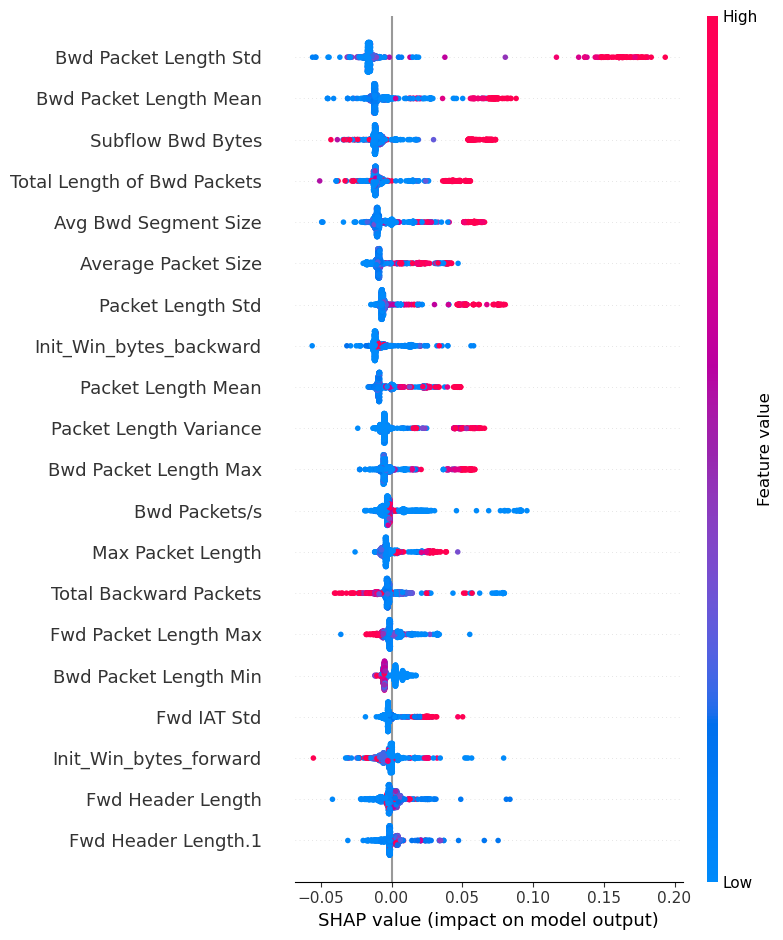

In [138]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_shap
)

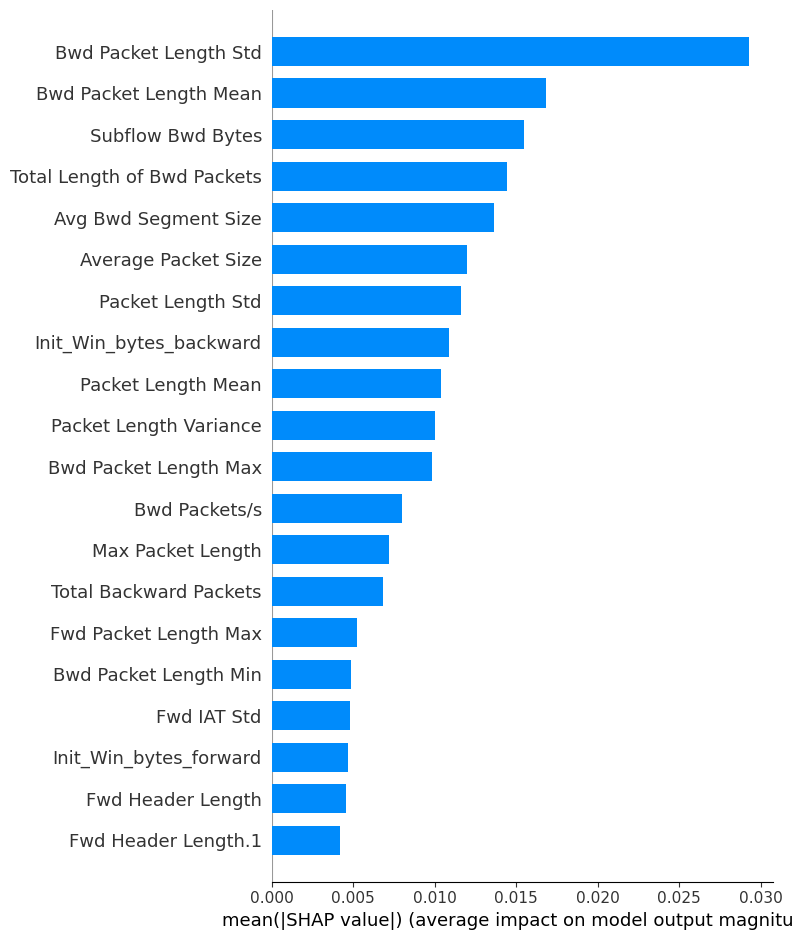

In [139]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_shap,
    plot_type="bar"
)

In [140]:
import pandas as pd
import numpy as np


shap_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "SHAP Importance": np.abs(shap_values.values).mean(axis=0)
})


shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)


shap_importance.head(20)

NameError: name 'X_test_sample' is not defined

In [141]:
%who

ConfusionMatrixDisplay	 LogisticRegression	 RandomForestClassifier	 StandardScaler	 X	 X_test	 X_test_scaled	 X_test_shap	 X_train	 
X_train_scaled	 accuracy_score	 bottom_corr	 classification_report	 corr	 df	 df_analysis	 df_ml	 df_original	 
df_sample	 explainer	 feature_importance	 log_reg	 missing	 np	 numeric_df	 pd	 plt	 
rf	 roc_auc_score	 scaler	 shap	 shap_values	 sns	 top10	 top_attacks	 top_corr	 
top_ports	 train_test_split	 y	 y_pred	 y_pred_rf	 y_proba	 y_proba_rf	 y_test	 y_train	 



In [142]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean_SHAP": np.abs(shap_values.values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance.head(20)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [143]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance.head(20)

ValueError: Per-column arrays must each be 1-dimensional

In [144]:
shap_values.shape


(1000, 77, 2)

In [145]:
shap_attack = shap_values[:, :, 1]
feature_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Mean_SHAP": np.abs(shap_attack).mean(axis=0)
})


feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance.head(20)

NameError: name 'X_test_sample' is not defined

In [146]:
shap_attack = shap_values[:, :, 1]
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": np.abs(shap_attack).mean(axis=0)
})


feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance.head(20)

,Feature,Mean_SHAP
12,Bwd Packet Length Std,0.029293
11,Bwd Packet Length Mean,0.016827
64,Subflow Bwd Bytes,0.015491
4,Total Length of Bwd Packets,0.014412
53,Avg Bwd Segment Size,0.013607
51,Average Packet Size,0.011954
40,Packet Length Std,0.011619
66,Init_Win_bytes_backward,0.010902
39,Packet Length Mean,0.010404
41,Packet Length Variance,0.010035


In [147]:
top5 = shap_importance.head(5)["Feature"].tolist()

top10 = shap_importance.head(10)["Feature"].tolist()

top20 = shap_importance.head(20)["Feature"].tolist()

top40 = shap_importance.head(40)["Feature"].tolist()

NameError: name 'shap_importance' is not defined

In [148]:
top5 = feature_importance.head(5)["Feature"].tolist()

top10 = feature_importance.head(10)["Feature"].tolist()

top20 = feature_importance.head(20)["Feature"].tolist()

top40 = feature_importance.head(40)["Feature"].tolist()

In [149]:
print(top20)

['Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Subflow Bwd Bytes', 'Total Length of Bwd Packets', 'Avg Bwd Segment Size', 'Average Packet Size', 'Packet Length Std', 'Init_Win_bytes_backward', 'Packet Length Mean', 'Packet Length Variance', 'Bwd Packet Length Max', 'Bwd Packets/s', 'Max Packet Length', 'Total Backward Packets', 'Fwd Packet Length Max', 'Bwd Packet Length Min', 'Fwd IAT Std', 'Init_Win_bytes_forward', 'Fwd Header Length', 'Fwd Header Length.1']


In [151]:
X_train_5 = X_train[top5]

X_test_5 = X_test[top5]
X_train_10 = X_train[top10]

X_test_10 = X_test[top10]
X_train_20 = X_train[top20]

X_test_20 = X_test[top20]
X_train_40 = X_train[top40]

X_test_40 = X_test[top40]
print(X_train.shape)

print(X_train_20.shape)

(1759851, 77)
(1759851, 20)


In [152]:
from sklearn.ensemble import RandomForestClassifier
import time


def train_random_forest(X_train, y_train):

    start=time.time()

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train,y_train)

    training_time=time.time()-start

    return model, training_time

In [153]:
rf_40, time_40 = train_random_forest(
    X_train_40,
    y_train
)

In [154]:
rf_20, time_20 = train_random_forest(
    X_train_20,
    y_train
)

In [155]:
rf_10, time_10 = train_random_forest(
    X_train_10,
    y_train
)

In [156]:
rf_5, time_5 = train_random_forest(
    X_train_5,
    y_train
)

In [157]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluate_model(model,X_test,y_test):

    prediction=model.predict(X_test)

    probability=model.predict_proba(X_test)[:,1]

    return {

        "Accuracy":
        accuracy_score(y_test,prediction),

        "Precision":
        precision_score(y_test,prediction),

        "Recall":
        recall_score(y_test,prediction),

        "F1-score":
        f1_score(y_test,prediction),

        "ROC-AUC":
        roc_auc_score(y_test,probability)

    }

In [158]:
results=[]

In [159]:
results.append({

"Model":"RF-All",

"Features":77,

"Training Time":time_77,

**evaluate_model(
    rf_77,
    X_test,
    y_test
)

})

NameError: name 'time_77' is not defined

In [160]:
results.append({

"Model":"RF-SHAP20",

"Features":20,

"Training Time":time_20,

**evaluate_model(
    rf_20,
    X_test_20,
    y_test
)

})

In [161]:
results.append({

"Model":"RF-SHAP20",

"Features":40,

"Training Time":time_40,

**evaluate_model(
    rf_40,
    X_test_40,
    y_test
)

})

In [162]:
results.append({

"Model":"RF-SHAP20",

"Features":10,

"Training Time":time_10,

**evaluate_model(
    rf_10,
    X_test_10,
    y_test
)

})

In [163]:
results.append({

"Model":"RF-SHAP20",

"Features":5,

"Training Time":time_5,

**evaluate_model(
    rf_5,
    X_test_5,
    y_test
)

})

In [164]:
results_df=pd.DataFrame(results)

results_df

,Model,Features,Training Time,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,RF-SHAP20,20,513.085290,0.998941,0.995742,0.997340,0.996541,0.999915
1,RF-SHAP20,40,830.331241,0.999039,0.997604,0.996107,0.996855,0.999891
2,RF-SHAP20,10,391.554246,0.991052,0.996895,0.944443,0.969960,0.998991
3,RF-SHAP20,5,289.578718,0.962542,0.995902,0.758247,0.860975,0.978013


ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

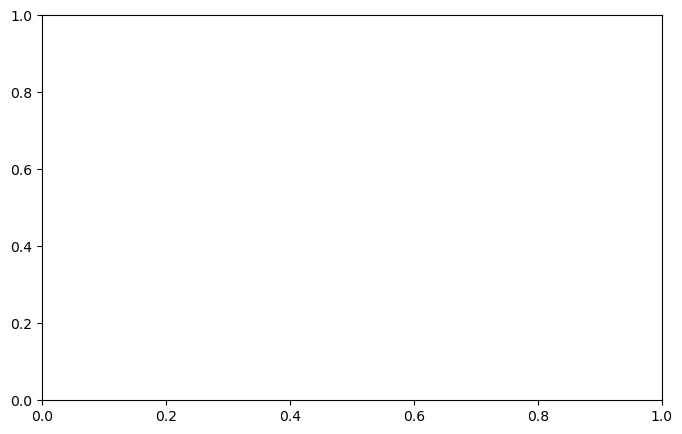

In [165]:
import matplotlib.pyplot as plt

features = [77, 40, 20, 10, 5]

accuracy = [...]
precision = [...]
recall = [...]
f1 = [...]

plt.figure(figsize=(8,5))

plt.plot(features, accuracy, marker='o', label="Accuracy")
plt.plot(features, precision, marker='s', label="Precision")
plt.plot(features, recall, marker='^', label="Recall")
plt.plot(features, f1, marker='d', label="F1-score")

plt.gca().invert_xaxis()

plt.xlabel("Number of Features")
plt.ylabel("Performance (%)")
plt.title("Performance Comparison Across SHAP Feature Subsets")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Performance_Comparison_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

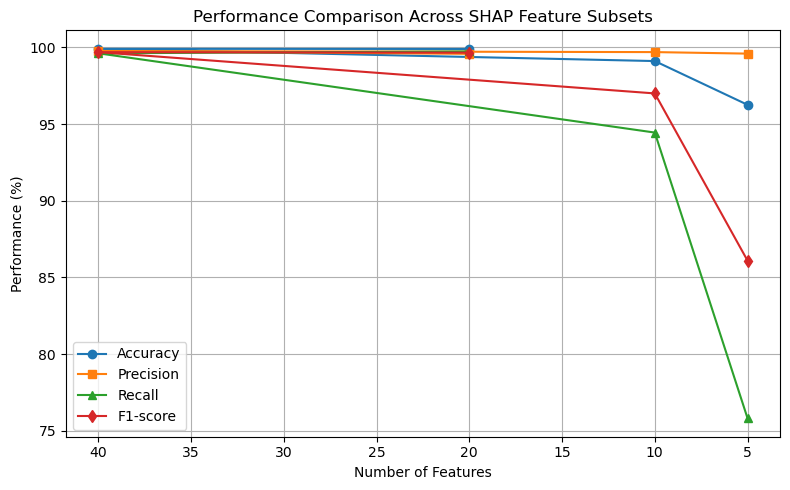

In [166]:
import matplotlib.pyplot as plt

features = results_df["Features"]

accuracy = results_df["Accuracy"] * 100
precision = results_df["Precision"] * 100
recall = results_df["Recall"] * 100
f1 = results_df["F1-score"] * 100

plt.figure(figsize=(8,5))

plt.plot(features, accuracy, marker='o', label='Accuracy')
plt.plot(features, precision, marker='s', label='Precision')
plt.plot(features, recall, marker='^', label='Recall')
plt.plot(features, f1, marker='d', label='F1-score')

plt.gca().invert_xaxis()

plt.xlabel("Number of Features")
plt.ylabel("Performance (%)")
plt.title("Performance Comparison Across SHAP Feature Subsets")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [167]:
import matplotlib.pyplot as plt

features = [77, 40, 20, 10, 5]

training_time = [
    time_77,
    time_40,
    time_20,
    time_10,
    time_5
]

plt.figure(figsize=(7,5))

plt.plot(
    features,
    training_time,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.gca().invert_xaxis()

plt.xlabel("Number of Features")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time vs Number of Selected Features")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Training_Time_vs_Number_of_Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'time_77' is not defined

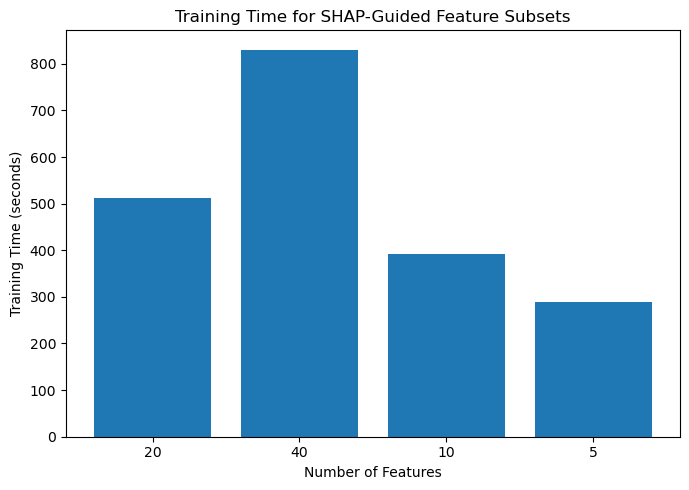

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    results_df["Features"].astype(str),
    results_df["Training Time"]
)

plt.xlabel("Number of Features")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time for SHAP-Guided Feature Subsets")

plt.tight_layout()

plt.savefig(
    "Training_Time_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()